# Boolean models

In [13]:
# === PARAMETERS ===
boolean_file = "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Boolean_model_BoNesis/Bonesis_13/attractors.csv"  # Attractors vectors
data_file = "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Boolean_model_BoNesis/Bonesis_13/data_binarized_tf_gene_sep.csv"  # Final states vectors
output_directory = "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Plots"

In [9]:
import sys
import json
import scanpy as sc
import numpy as np
import pandas as pd
import gc
import warnings
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import bonesis
import pyreadr
import ast
import seaborn as sns

## 1) Extract the attractors from the model .bnet and the phenotype from the data

In [21]:
attractors = pd.read_csv(boolean_file,index_col=0)
print(attractors.shape)
attractors.head()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
(4, 579)


,ABCA1,ABCB1,ABI3,ACOT7,ACP5,ACYP2,ADAM19,ADAM9,ADSL,AIFM2,AK1,AKAP12,ALDH1A1,ALDH2,ALOX5,ANAPC15,ANK2,ANXA1,ANXA2,ANXA5,APEX1,APOC2,APOD,APOE,APRT,ARHGDIA,ARHGDIB,ARL4C,ARRB2,ARRDC3,ATF3,ATF4,ATF5,ATF6,ATF7IP,ATG4A,ATOX1,ATP2A3,ATP8A1,AURKAIP1,AUTS2,B4GALT1,BANF1,BATF,BCAS3,BCAT1,BCL2A1,BCL6,BHLHE41,BID,BIRC3,BLMH,BLOC1S1,BLVRA,BNIP3L,BRCA2,BSG,BTG3,C1QA,C1QB,C1QBP,CA3,CACNB2,CALR,CAMK1D,CAPG,CASP1,CASP4,CAT,CBLB,CCL13,CCL2,CCL3,CCL4,CCL8,CCND2,CCR6,CCT6A,CD14,CD24,CD27,CD38,CD40,CD59,CD63,CD68,CD83,CD9,CDA,CDC25B,CDK2AP1,CDK5,CDKN1A,CDKN1C,CEBPA,CEBPB,CEBPD,CEBPG,CERK,CHI3L1,CHRNB1,CIITA,CKS2,CLASRP,CLEC7A,CLOCK,CNR1,COL4A3,COMMD7,COX17,COX5B,COX6A1,CRABP2,CREB1,CREB5,CREG1,CRTC1,CRY1,CST3,CSTA,CSTB,CTSB,CTSC,CTSD,CTSL,CUBN,CUX1,CXCL10,CXCL8,CXCL9,CXCR3,CXCR4,CXXC5,CYBB,CYBRD1,CYCS,CYP1B1,CYP27A1,CYSLTR1,DAB1,DAB2,DAPK2,DBI,DCSTAMP,DCTN6,DDAH1,DDB2,DDIT3,DDIT4,DDT,DDX60L,DGKG,DHRS3,DIAPH2,DNAJC1,DNASE2,DNPH1,DRAM2,DSTN,E2F4,EFHC1,EFHD2,EGR1,EGR2,EIF4A1,EIF4EBP1,EIF5A,ELL2,EMP1,ENO1,ENPP2,EPB41,EPB41L3,EPSTI1,ERAP2,ESR1,ESR2,ETF1,ETS1,EXT1,F13A1,F5,FABP3,FABP5,FASTK,FBP1,FCER1G,FCGR1A,FCGR3A,FCRL1,FCRL5,FER,FGL2,FHIT,FKBP4,FLCN,FN1,FNDC3B,FOS,FOXO1,FRMD5,FYB1,GAPDH,GATA3,GATM,GCHFR,GLIPR1,GLRX,GLUL,GPNMB,GPX4,GRIN2B,GSN,GUCY2C,HAMP,HCK,HERC5,HERPUD1,HIF1A,HIP1,HIVEP1,HMBS,HMGA1,HNMT,HOXA1,HS1BP3,HS2ST1,HSPA5,HSPA8,HSPB1,HSPD1,HSPE1,ICOS,IER2,IER3,IER5,IFI27,IFI30,IFI6,IFIT1,IFIT2,IFIT3,IFITM3,IKZF2,IL10RA,IL15,IL18,IL1RN,IL2RA,IL2RB,IL32,IL3RA,IL4R,IL7,IMPACT,IMPDH1,IMPDH2,IRAK2,IRF1,IRF4,ITGB2,ITGB7,JPT1,JUNB,JUND,KANK1,KAT2B,KCNC1,KCND2,KCNMA1,KCNQ5,KDM3A,KDM7A,KLF1,KLF12,KLF13,KLF2,KPNA2,L1TD1,LAT2,LCN8,LDHA,LDHB,LEF1,LEPR,LGALS1,LGALS3,LILRB1,LILRB4,LMO2,LRRC59,LTB,LYRM4,LYZ,MAFB,MAML2,MAP2,MAP2K1,MAP3K1,MAP3K11,MAP3K8,MAPK8,MAPKAPK3,MARCKS,MATK,MAZ,MBTPS2,MCU,ME1,MECP2,MEF2A,MGLL,MITF,MLLT3,MMP9,MNDA,MRC1,MRPL17,MRPL21,MRPL27,MRPL41,MRPS24,MSR1,MT1E,MT1F,MT2A,MTHFD1L,MTHFD2,MTSS1,MTX1,MX1,MX2,MXD1,MXI1,MYBL2,MYC,MYCN,MYO1E,MYOD1,MYOM1,NAMPT,NCF2,NCF4,NDRG1,NDUFA6,NDUFAF2,NDUFAF3,NEK6,NEO1,NFE2L2,NFKBIA,NFKBIB,NINJ1,NME1,NME2,NOTCH2,NR1D2,NR1H3,NR1I2,NRIP1,NUPR1,NUTF2,NXT1,ODC1,ONECUT1,PABPC4,PAPSS1,PATJ,PCBD1,PDE7B,PDGFD,PDIA6,PDLIM7,PEA15,PEG10,PEPD,PGD,PHB2,PIGR,PIK3CA,PKIB,PKM,PLA2G7,PLAAT4,PLAC8,PLAGL1,PLAUR,PLCG2,PLEK,PLSCR1,PML,PMVK,PNP,POU2AF1,POU2F1,PPA1,PPDPF,PPIF,PPP1R15A,PPP1R7,PRDX1,PRDX3,PRDX5,PRKCE,PRKN,PROCR,PRXL2A,PSAP,PSMA4,PSMA6,PSMB5,PSMB6,PSMC2,PSMC5,PSMD11,PSMG1,PTGDS,PTH2R,PTPN11,PTPRG,PTTG1,PUF60,PYCARD,RAB13,RAB20,RAB31,RAB34,RAC1,RARB,RASGEF1B,RBM3,RBP1,RBPJ,RCAN1,RELA,RELB,RGCC,RGS10,RGS2,RHOC,RNASE1,RNF14,RNF144B,RNH1,ROR1,RORA,RPS6KA5,S100A10,S100A11,S100A13,S100A4,S100A8,S100A9,SAMD7,SAMD9L,SAMHD1,SARS2,SAT1,SCD,SCFD2,SDC2,SDCBP,SELENOH,SELENOP,SELENOS,SELL,SELP,SELPLG,SEMA4B,SERP1,SERPINA1,SERPINF1,SESN3,SFMBT1,SFTPB,SGK1,SGK3,SH3BP2,SHMT2,SLAMF7,SLC14A1,SLC1A5,SLC25A19,SLC25A3,SLC25A5,SLC2A13,SLC3A2,SLC7A5,SMS,SMYD3,SNRPB,SOD2,SOX2,SP1,SPI1,SPOCK2,SPP1,SRGN,SRM,SSBP3,ST3GAL5,ST6GALNAC3,SUB1,SUMO3,SUPT3H,SURF2,SYNGR2,TACR1,TAF10,TAF4B,TAF9,TAL1,TALDO1,TBP,TESK1,TFEC,TFPT,TFRC,THOP1,TIGAR,TIMP1,TKT,TMEM126A,TNFAIP2,TNFRSF18,TNFRSF4,TNFSF10,TNFSF12,TNFSF13,TNFSF13B,TP53,TPD52,TPI1,TPK1,TPM2,TRIAP1,TRIB3,TRIM14,TRIM22,TRIP6,TRPS1,TSC22D3,TSFM,TSPO,TTN,TUBA1B,TUBB,TUBG1,TXN,TXN2,TXNIP,TYMP,TYROBP,UBE2S,UCHL3,UCK2,UGDH,UPP1,UQCRC1,UQCRQ,UROS,UST,UTRN,UTY,VAV3,VDAC1,VEGFB,VIPR1,WDFY4,WT1,WWOX,XAF1,XBP1,XRN1,YWHAG,ZEB1,ZNF569,ZNF611,ZNRF2
Attractor,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,

In [23]:
data = pd.read_csv(data_file,index_col=0)
print(data.shape)
data.head()

(4, 2632)


AAMDC  ABCA1  ABCA10  ABCA5  ABCA9  ABCB1  ABCB4  ABCC5  ABCD2  \
macrostate                                                                   
S0            NaN    NaN     1.0    NaN    1.0    1.0    NaN    NaN    1.0   
S11           1.0    1.0     NaN    NaN    NaN    1.0    1.0    NaN    NaN   
S2            0.0    NaN     0.0    0.0    0.0    0.0    0.0    0.0    NaN   
S3            0.0    0.0     0.0    NaN    NaN    0.0    0.0    NaN    0.0   

            ABCD3  ABCF1  ABCG1  ABHD18  ABHD3  ABHD5  ABI2  ABI3  ABL1  ABL2  \
macrostate                                                                      
S0            1.0    NaN    NaN     1.0    1.0    NaN   NaN   NaN   1.0   1.0   
S11           NaN    0.0    NaN     NaN    NaN    NaN   NaN   NaN   NaN   NaN   
S2            0.0    0.0    NaN     0.0    NaN    NaN   0.0   1.0   NaN   0.0   
S3            NaN    1.0    0.0     NaN    0.0    1.0   NaN   0.0   NaN   NaN   

            ABR  ABRACL  ACACA  ACAD11  ACADSB  ACBD6  ACER2  ACMSD  ACO1  \
macrostate                                                                  
S0          1.0     0.0    NaN     1.0     NaN    NaN    NaN    1.0   NaN   
S11         1.0     0.0    0.0     NaN     NaN    NaN    NaN    NaN   NaN   
S2          0.0     0.0    0.0     0.0     0.0    0.0    0.0    NaN   NaN   
S3          0.0     1.0    NaN     NaN     NaN    NaN    NaN    NaN   0.0   

            ACOT7  ACOXL  ACP5  ACP6  ACSL1  ACSM1  ACSM3  ACSM6  ACTG1  \
macrostate                                                                
S0            NaN    NaN   NaN   1.0    NaN    1.0    1.0    1.0    0.0   
S11           0.0    0.0   0.0   NaN    0.0    1.0    1.0    NaN    0.0   
S2            NaN    0.0   NaN   NaN    NaN    0.0    0.0    0.0    NaN   
S3            1.0    1.0   0.0   NaN    1.0    0.0    0.0    NaN    1.0   

            ACTR3B  ACTR3C  ACTR6  ACVR1  ACVR2A  ACYP2  ADA2  ADAM10  ADAM19  \
macrostate                                                                      
S0             NaN     1.0    NaN    1.0     1.0    1.0   1.0     NaN     1.0   
S11            NaN     NaN    0.0    0.0     NaN    NaN   1.0     1.0     NaN   
S2             0.0     0.0    0.0    NaN     0.0    0.0   0.0     0.0     NaN   
S3             NaN     NaN    NaN    NaN     NaN    0.0   0.0     0.0     0.0   

            ADAM28  ADAM9  ADAMDEC1  ADAMTS6  ADARB1  ADD3  ADGRF3  ADHFE1  \
macrostate                                                                   
S0             1.0    NaN       0.0      1.0     NaN   1.0     1.0     1.0   
S11            1.0    0.0       NaN      NaN     NaN   1.0     NaN     NaN   
S2             0.0    NaN       1.0      0.0     NaN   0.0     NaN     NaN   
S3             0.0    1.0       NaN      0.0     1.0   0.0     NaN     0.0   

            ADK  ADTRP  AEBP1  AEBP2  AFF1  AFG1L  AGA  AGBL2  AGBL3  AGBL5  \
macrostate                                                                    
S0          NaN    1.0    NaN    1.0   1.0    1.0  NaN    NaN    1.0    NaN   
S11         NaN    1.0    NaN    NaN   NaN    NaN  NaN    NaN    NaN    NaN   
S2          0.0    0.0    NaN    0.0   0.0    0.0  NaN    NaN    0.0    0.0   
S3          NaN    0.0    0.0    0.0   0.0    NaN  1.0    0.0    NaN    NaN   

            AGK  AGO3  AGO4  AGPAT4  AGPAT5  AGTPBP1  AGTRAP  AHCYL2  AHI1  \
macrostate                                                                   
S0          NaN   1.0   1.0     1.0     1.0      1.0     NaN     1.0   1.0   
S11         NaN   1.0   NaN     NaN     1.0      NaN     0.0     NaN   NaN   
S2          0.0   0.0   NaN     NaN     0.0      0.0     NaN     0.0   0.0   
S3          NaN   0.0   0.0     0.0     1.0      NaN     NaN     NaN   NaN   

            AHNAK  AHR  AIF1  AIFM1  AIG1  AK1  AK6  AK9  AKAP12  AKAP7  \
macrostate                                                                
S0            1.0  NaN   0.0    NaN   NaN  NaN  0.0  1.0     NaN    NaN   
S11           NaN

In [24]:
# Common genes
common_genes = attractors.columns.intersection(data.columns)

# Subset
attractors = attractors[common_genes]
data = data[common_genes]

print(f"Commons genes : {len(common_genes)}")
print("Attractors :", attractors.shape)
print("Data       :", data.shape)

Nombre de gènes communs : 445
Attractors : (4, 445)
Data       : (4, 445)


## 3) Evaluate the attractors

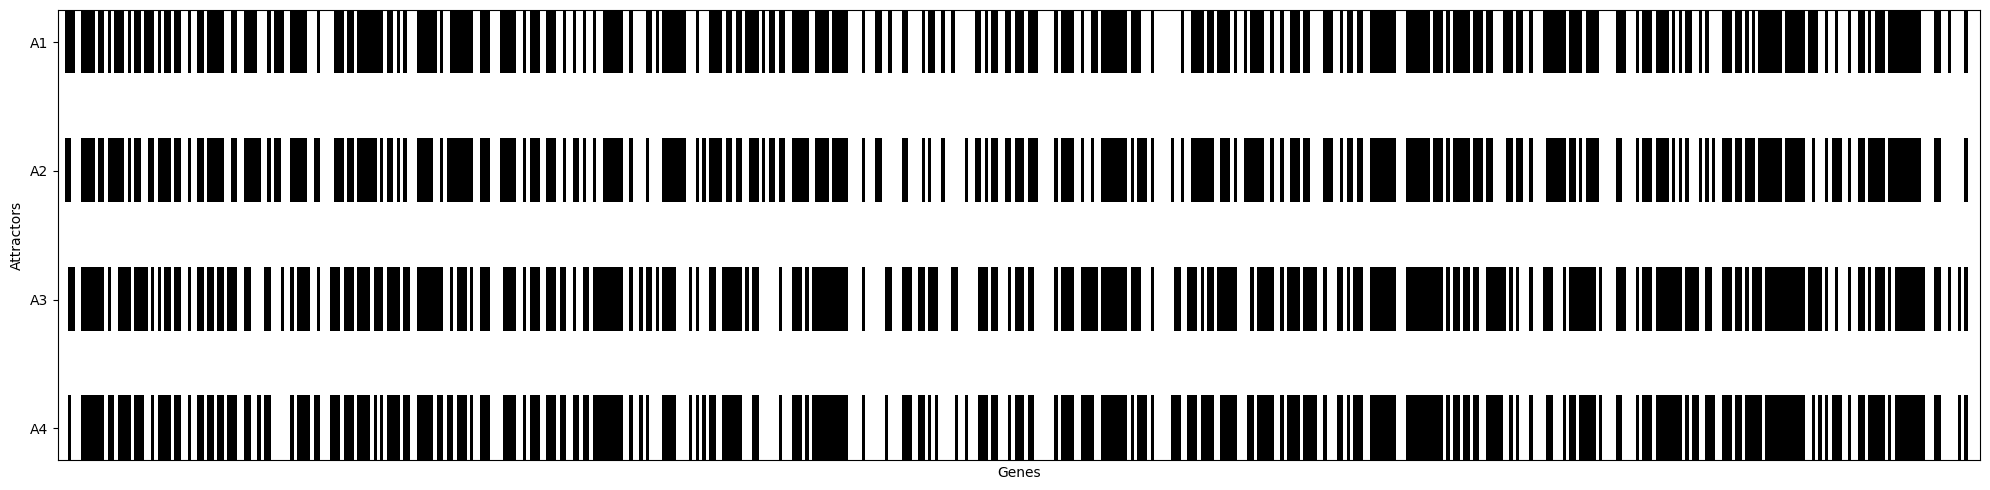

In [25]:
mat = df.values
n_rows, n_cols = mat.shape

mat_spaced = np.full((n_rows * 2 - 1, n_cols), np.nan)
mat_spaced[::2] = mat 
# Colormap : black = 1, white = 0
cmap = plt.cm.binary.copy()
cmap.set_bad(color="white")

fig, ax = plt.subplots(figsize=(20, 5))

ax.imshow(
    mat_spaced,
    cmap=cmap,
    aspect="auto",
    interpolation="none")

# Not genes names 
ax.set_xticks([])

ax.set_yticks(np.arange(0, n_rows * 2 - 1, 2))
ax.set_yticklabels([f"A{i+1}" for i in range(n_rows)])

ax.set_xlabel("Genes")
ax.set_ylabel("Attractors")

plt.tight_layout()
plt.show()

Similarity matrix 

In [29]:
similarity = pd.DataFrame(
    index=attractors.index,
    columns=data.index,
    dtype=float
)

for attr_name, attr_row in attractors.iterrows():
    for data_name, data_row in data.iterrows():
        similarity.loc[attr_name, data_name] = np.mean(
            attr_row.values == data_row.values
        )

print(similarity)

macrostate        S0       S11        S2        S3
Attractor                                         
Attractor1  0.065169  0.096629  0.644944  0.514607
Attractor2  0.053933  0.089888  0.588764  0.579775
Attractor3  0.071910  0.096629  0.485393  0.680899
Attractor4  0.060674  0.089888  0.429213  0.746067


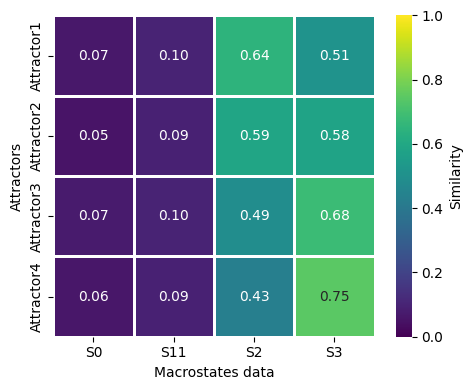

In [31]:
plt.figure(figsize=(5,4))

sns.heatmap(
    similarity,
    annot=True,
    cmap="viridis",
    vmin=0,
    vmax=1,
    square=True,
    linewidths=1,
    fmt=".2f",
    cbar_kws={"label": "Similarity"}
)

plt.xlabel("Macrostates data")
plt.ylabel("Attractors")
plt.tight_layout()
plt.show()